<a href="https://colab.research.google.com/github/ankitsingh435517/nn/blob/main/makemore1_impl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement the makemore part 1 the bigram model from memory



In [129]:
# Without a neural net using a probability tensor.

In [130]:
# what is the task at hand ?
# we need to train a bigram model
# A bigram model is a type of model which predicts the probability of the next character when inputed a character.
# Now next character can mean different things here, so specifically what we want is we want to predict the next char
# from the probability distribution from the training dataset - now the training dataset can represent anything from a curated list
# of names to a language vocabulary etc.
# Here we have the list of names in english langauge like emma, mark, max, john, joe - here e follows m, m follows m and m follows a then j follows o and so on
# so here the probability of e following m and m following m or a will be higher than e following k or t specifically in this dataset we have.

In [131]:
# so we need to create the probability distribution normalised for us to create a prediction sample for any given character.
# first import the dataset
# split it on words and then create the bigram frequency count where we take a word and create the bigrams and count through out the dataset
import requests

url = 'https://raw.githubusercontent.com/karpathy/makemore/master/names.txt'
response = requests.get(url)
words = response.content.decode('utf-8').splitlines()

In [132]:
# now we have the words split to work with
# we need to iterate on each word to create bigrams counts
# we can use something like a matrix which can bound every char which we need as the characters are bounded under 26 alphabets from a to z
# so we need a matrix of 26 x 26 where each row tells us the count of first char to follow second char probability example row of e say 4th row (o based index)
# will have the whole row of e following all the chars from a to z as ea, eb, ec, ed, ef ... ez

# one more thing to ensure here is that the names predicted finally by our bigram model must end somewhere and must start somewhere example a special character of sorts
# which can tell how likely is this beginning of name to follow a char and how often is this ending of name being followed by other chars example <bos> and <eos>
# <bos> follows e strongly like the probability is higher amongst all the chars and n follows <eos> strongly as in the probability of n following <eos> is higher
# so we need these two chars added in the matrix to represent their rows and cols but one more thing that <eos> can never follow any char and <bos can never be followed
# in other words no column of <eos> will have any probability as in 0 probability or for every row to have a column where it tells how likely it is to follow <bos> will all be 0 which is wasteful and we don't really want it to come into computations later on.

# to prevent this column and row of all zeros we can use a special char to cater both these chars <bos> and <eos> with '.' now it will have a single row which tells us that how likely
# '.' to follow all other chars and one column which tells for all chars that how likely they are to follow '.' now since we are hiding away the explicitness of adding <bos> and <eos> we will avoid the row of <eos> as the '.' will now take up the row to represent <bos> but when it has to represent <eos> we do not allow but again the column will represent for <eos>

# we extend each of the word with adding '.' + list(w) + '.'
# this will give '.' the way to create its row to represent <bos> but then '.' will not be given the chance to do so as in there will be no such bigrams possible example 'emma' -> .emma. now we run bigram pointers from . and e until either of it exhausts so the bigrams will be
# .e | em | mm | ma | a.
# now the second pointer is exhausted but first pointer is at '.' which is representing the <eos> here if we had allowed it to be a bigram which it can't pair with anyway it would want to create an <eos> row here '.' would overrite the <bos> row '.'

In [133]:
# so we need a 27 x 27 matrix to store the count of bigrams
import torch
import string

# 27 x 27 tensor to store the probability distribution of bigrams in the dataset
N = torch.zeros((27, 27), dtype=torch.float32)

# 'a' to 'z'
alphabets = list('.' + string.ascii_lowercase)

itoc = {} # integer to character e.g 5 -> e
ctoi = {} # character to integer e.g e -> 5
for index, value in enumerate(alphabets):
  itoc[index] = value
  ctoi[value] = index


for w in words:
  # two pointers to create bigrams
  chars = '.' + w + '.'
  for ch1, ch2 in list(zip(chars, chars[1:])):# from '.' and 'e' in the case of word '.emma.' will give .e | em | mm | ma | a.
    # ch1 is the row which says how likely is ch1 to follow ch2 we can say ch1 becomes our input and for model to do well it needs to predict ch2 accurately
    # now we need a way to index char to int so we can target the correct row and cols - itoc and ctoi are the maps which gives integer to char and char to integer
    row = ctoi[ch1]
    col = ctoi[ch2]
    N[row][col] += 1 # count the bigrams

N[0].sum()


tensor(32033.)

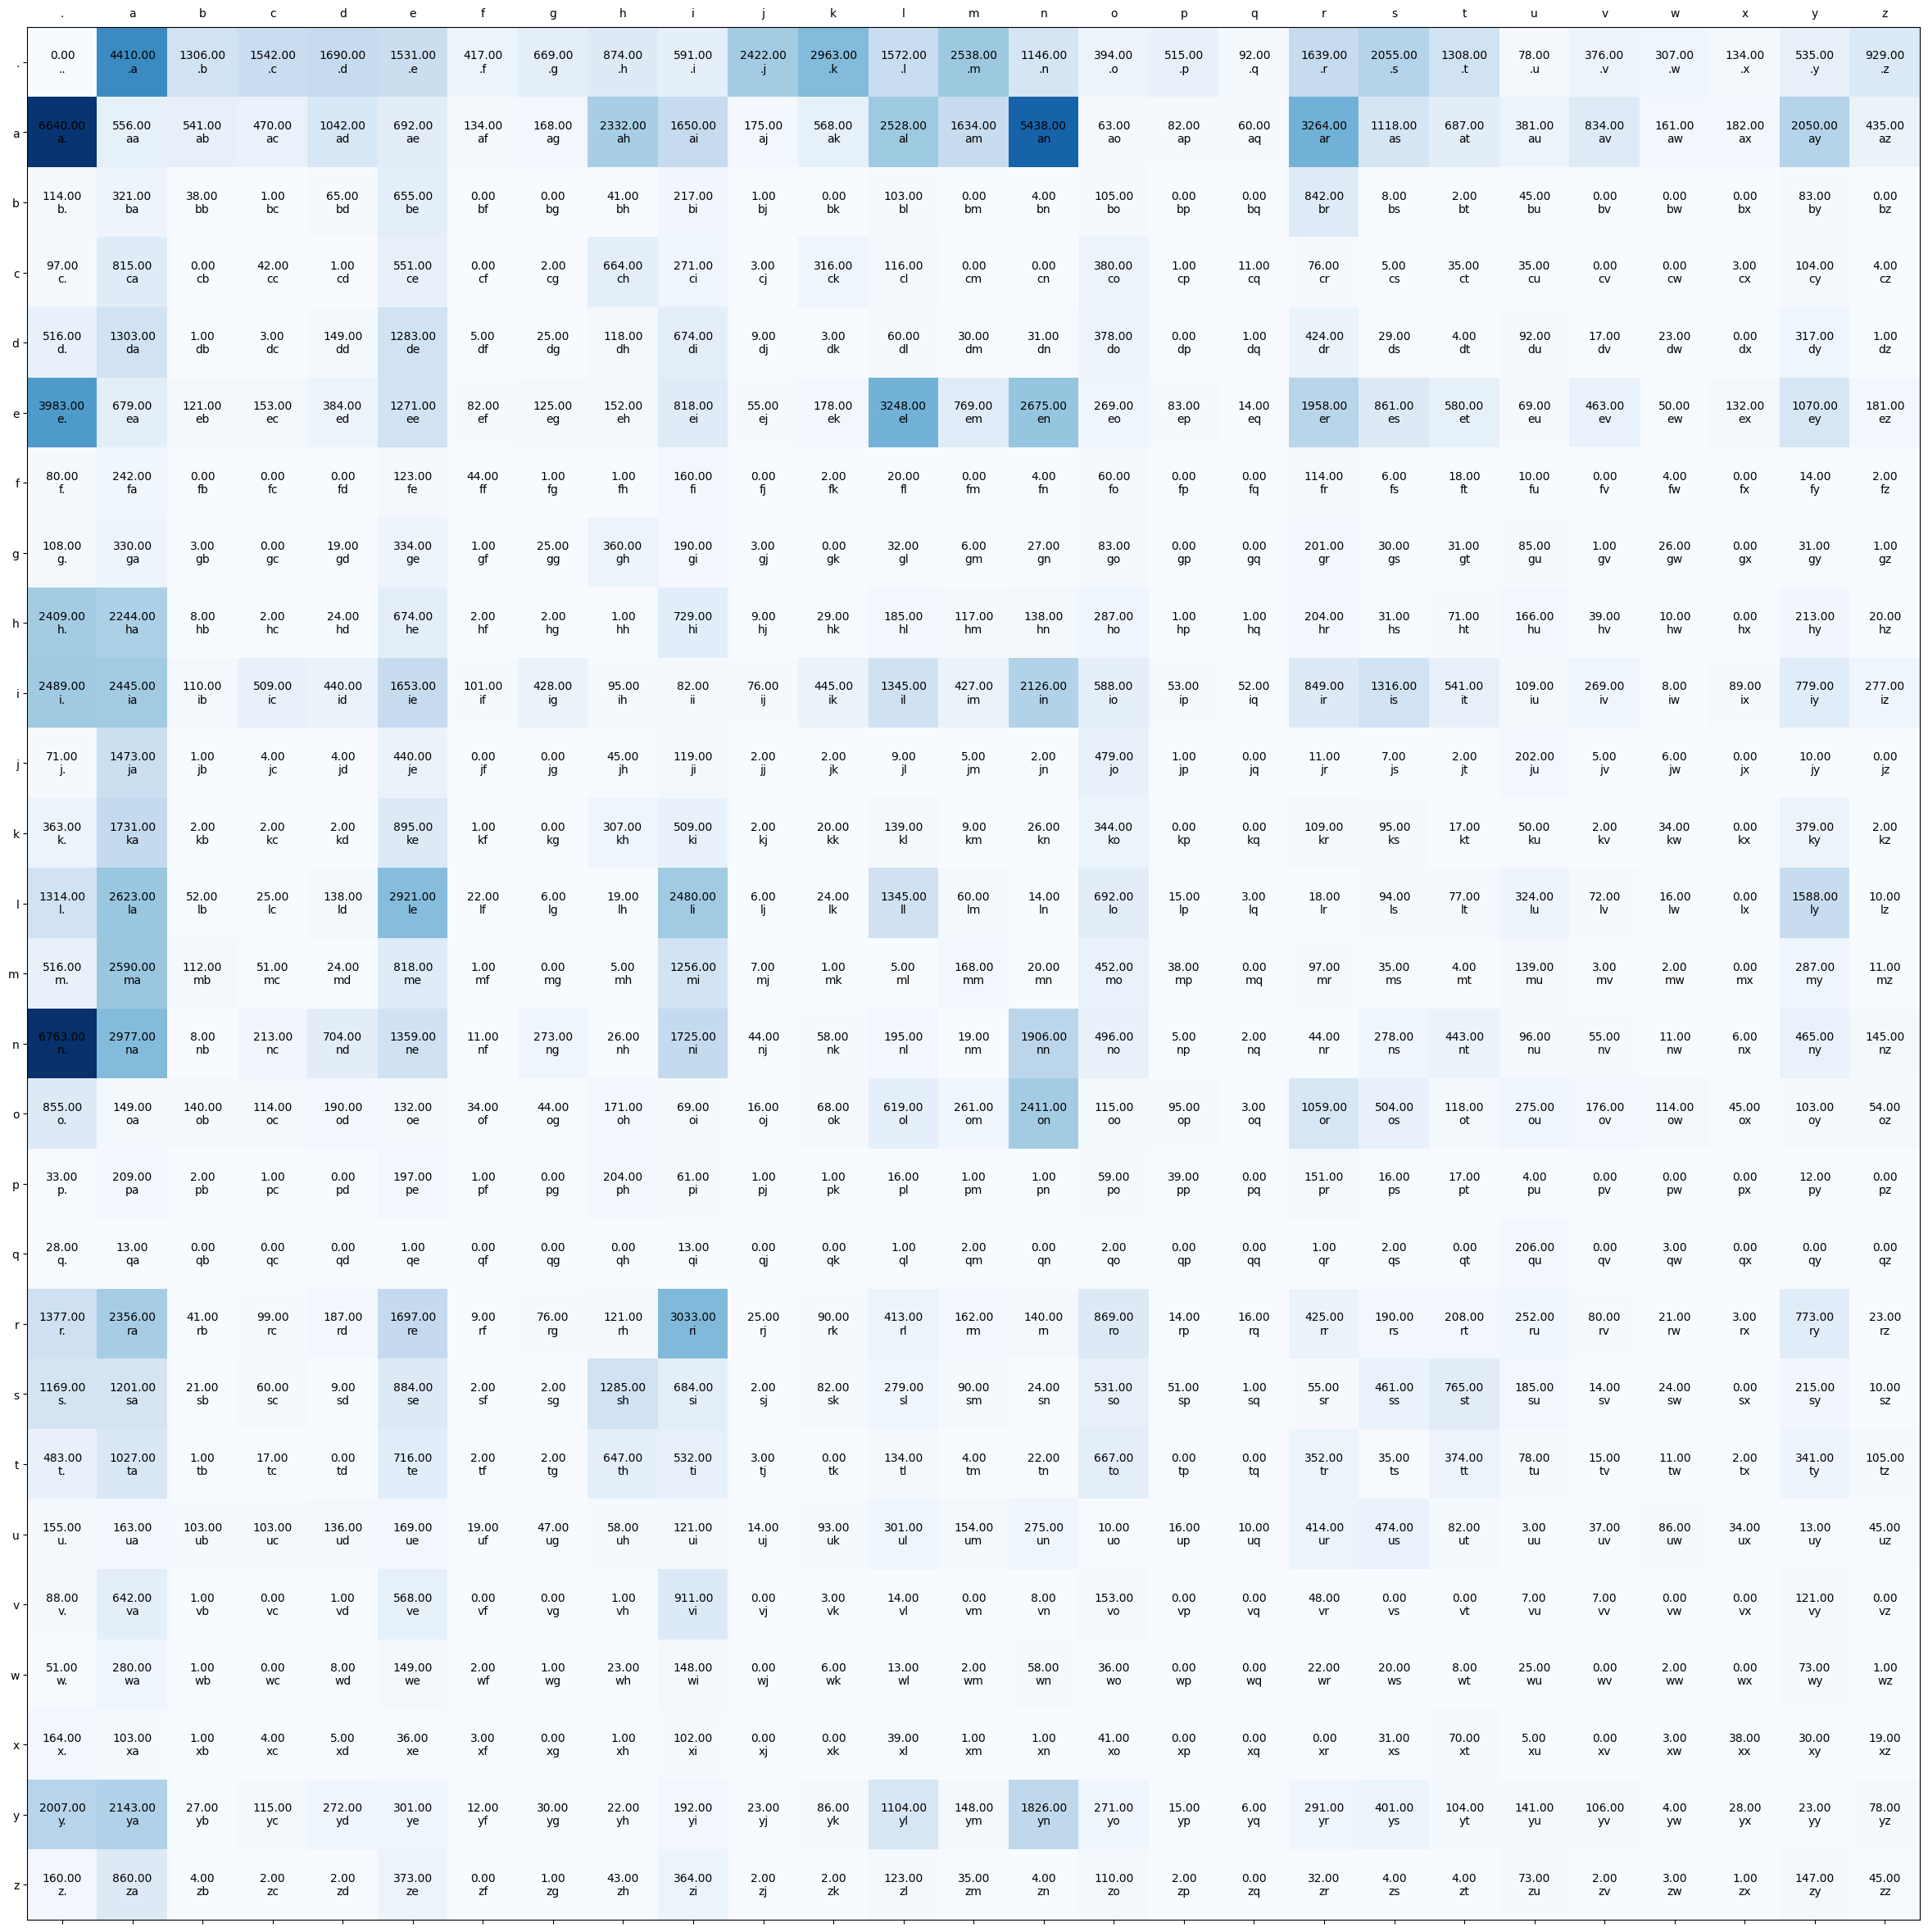

In [134]:
# now we are capturing the bigrams probability correctly as we can visualize it to verify this
# we can use imshow from matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 30))

plt.imshow(N, cmap='Blues', origin="upper")

shape = N[0].shape
size = shape[0]

# Row and column indixes
plt.xticks(range(size), alphabets) # labels for each column aka the 2nd char
plt.yticks(range(size), alphabets) # labels for each row aka the 1st char

plt.tick_params(axis='x', labeltop=True, labelbottom=False)

for i in range(27):
  for j in range(27):
    ch1 = itoc[i]
    ch2 = itoc[j]
    plt.text(
        j, i, # j is the x axis (col) and i is the y axis (row)
        f"{N[i][j]:.2f}\n{ch1}{ch2}",
        ha="center",
        va="center"
    )

plt.show()

In [135]:
# Now we can see that the probability distriution is not normalized, so let's normalize the values for each row
# now here we want to do pi = pi / sum(p) where p is each row and pi is each column. so that it adds up to 1
# now we need to sum up all the columns for each of the rows and then divide each column of each row by the respective sum of that row.
# we can create a matrix of shape N x 1 where we have a single column for each row reflecting the sum of all the probabilities of that row
S = torch.zeros((27, 1))
S

for i in range(27):
  sum = 0
  for j in range(27):
    pi = N[i][j]
    sum += pi
  S[i] = sum

S

tensor([[32033.],
        [33885.],
        [ 2645.],
        [ 3532.],
        [ 5496.],
        [20423.],
        [  905.],
        [ 1927.],
        [ 7616.],
        [17701.],
        [ 2900.],
        [ 5040.],
        [13958.],
        [ 6642.],
        [18327.],
        [ 7934.],
        [ 1026.],
        [  272.],
        [12700.],
        [ 8106.],
        [ 5570.],
        [ 3135.],
        [ 2573.],
        [  929.],
        [  697.],
        [ 9776.],
        [ 2398.]])

In [136]:
# now we have the sum of all the columns for each of the row, now let's divide each column with the sum of its respective row
# ;et's clone the N, just incase we need the old probability matrix (un normalized)

P = N.clone()

for i in range(27):
  for j in range(27):
    pi = P[i][j]
    P[i][j] = pi / S[i]

# this can be done using an operation on tensors called as broadcasting which can be utilized given if we need the semantics to hold for the given task, here its a simple normalization so we can skip it


In [137]:
# summing using pytorch sum and dividing using broadcasting
# sum
S = N.sum(dim=1, keepdim=True)

P = N.clone()

# broadcasting
# broadcasting is essentially a division so it needs the rules of matrix divide or broadcasting semantics
# N x N can be broadcasted to , N or 1, N or N x N
# so that end result remains N x N as the row of first and col of second must be same, so when one of them is not there then N would be stretched for what is not present row or col
# if 1 is there then that is stretched to other axis
# at the end N x N must be true as in first's row x second's col to preserve the original matrix or tensor

# here we have S of shape 27 x 1 which is fine as the P is of shape 27 x 27
# here we have 27 rows of a single column each has the sum of all the columns so the 27 x 27 / 27 x 1 => 27 x 27
# now the missing columns would be stretched horizontally as in the columns are repeated with the first column and that is what we want
# we want each column to be divided by its respective row to be normalized

# quick zoom out: here the row tells what is the probability of this char being a start of the bigram as in how likely it is to follow other chars from 'a' to 'z'
# the normalization just gives the portion of total for each probability score.

P = P / S

In [138]:
P[0].sum()

tensor(1.)

In [175]:
# Now we have the normalized probability distribution with us, this is our bigram model
# now we can use our bigram model to predict the next character when input is given to generate a word which is biased towards the probability distribution we have for this dataset

# for input of a char we need the model to output a high probable char which the input char follows
# now we know the input must start from '.' the <bos> and whatever has the highest likelihood of being followed by '.' must be the next char and then that becomes the next input and then the char outputed to that input must be the high probable to be followed by that input
# this ends when a character is outputed which becomes the input and it has the highest probability to follow '.' the <eos> so that is where we conclude our word predicted by our model

# seed it with a manual seed for pseudo random, for same output to know its not garbage
torch.manual_seed(42)

# test emma


# let's generate some words
for r in range(10):
  out = []
  input = 'e'
  while True:
    # now we need a way to pick the char in the row of the input char as the row the input char says how likely it is that this char follow all other chars from a to z
    # so say '.' follows a 60%, '.' follows e 30% and j 10% so its like a bag of balls where we have 3 different colors of balls red, blue and green here red is 60% probable to be picked
    # blue to be 30% and green to be 10% now we would be more likely to pick red in multiple turns then blue then green, so similarly we have the same bag instead here we have 27 different colors and different probabilities of them being picked
    # so we need to use some proabability sampling function likewise.
    # this is conditional probability meaning we need the probability of the next char given the current char irrespective of any other prior chars also known as markov chain.
    # so for this we need to draw a single sample from the bag of balls here randomly but biased. We will use multionmial distribution in pytorch
    ix = ctoi[input] # row
    next = torch.multinomial(P[ix], num_samples=1, replacement=True).item()
    if next == 0:
      break
    out.append(itoc[next])
    input = itoc[next]

  pred = ''.join(out)
  print(pred)

anugeenvi
s
mabian
dan
stan
silaylelaremah
li
le
epiachalen
diza


In [ ]:
# we need to eval this model, we need to first find the loss
# what does loss here means ? given ch1 we want our model to predict ch2 correctly based on the probability distribution
# we need some score to be given so that we can see how far it is from the correct character
# so say the model predicted a char for for ch1 which is far from what is the correct output char we need the far is defined as ?
# after all it is range randomly sampled based on the probability distribution.

# we use something called as a log of the probability of the correct char example if e was supposed to be outputed when '.' was input but instead it sampled 's' then we check what was the probability assigned to 'e' and find the loss by doing -log(p['e'])
# why log ? so log takes in value between 0 < p <= 1 and it returns 0 for log(1) and higher when the p is lower so if the model thinks the correct output it gave has high probability
# say for a char it gave log(0.9) then the loss is very low in negative so we take -log(p) to get the positive value as in the positive loss and for when the p is 0.2 then the loss is high
# we need the loss of entire model and we do that by multiplying all the probabilities P(model) = P1*P2*P3...
# log helps us here as log(a * b) = log(a) + log(b)
# so we sum up all the negative log likelihoods and that becomes our total loss of the entire model.

# not clear on what becomes the test example and how evaluation works for finding loss - it has happened again after micrograd
# i am usually not clear on dataset split and how test data is used in the model evaluation - pay attention on this.

# i have the idea clear what to do but not sure how to implement the evaluation with test data.

In [176]:
# We have successfuly trained the bigram model to predict the next char given the current char based on the given dataset on its probability distribution.

# SUMMARY ================================================
# 1. Trained the bigram model
# 2. Couldn't implement training evaluation - also had forgot to consider - pay attention from the data pipeline setup
# ========================================================
# ---------------------------------------------------------x----------------------------------------------------

In [ ]:
# Neural network bigram model starts here.
# how does the bigram network model would work ?
# so the neural network needs an input char and must output a char which is most likely to be the char that follows
# but neural net doesn't take char as input but a one hot encoding vector and returns logits ? what is logits ?
# what is a neural net here ? is it the same as bigram model just with grad and backward to do the gradient descent ?
# Let's break down the fundamental processes of a neural net
# 1. Forward pass
# 2. Back prop

# So what does a forward pass looks like for a neural net ?
#